In [1]:
from sklearn.decomposition import PCA
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import griddata


    curvatures_sub = (labels_sub, curv_in_sub, curv_rec_sub, curv_lat_sub, curv_lat_norm_sub, curv_true,curv_learned)
    curvatures_emp_full = (labels, curv_in, curv_lat, curv_lat_norm, curv_rec)


# Dimension 1

In [30]:
def plot_curvatures_single_figure(base_path, file_paths, labels, save_path):
    n_files = len(file_paths)
    # Load latent curvatures
    latent_curvatures = []
    for path in file_paths:
        data = torch.load(base_path + path, weights_only=False)
        latent_curvatures.append(data['curvatures_sub'][6])
    
    # Load angles and true curvature
    reference_data = torch.load(base_path + file_paths[0], weights_only=False)
    angles = reference_data['curvatures_sub'][0]
    true_curvature = reference_data['curvatures_sub'][5]
    
    # Labels and colors
    labels_list = [f'Learned Curv. {label}' for label in labels]
    colors = ['tab:blue', 'tab:orange', 'tab:red', 'tab:purple']
    
    # Plot all on one axis
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot true curvature in green
    ax.plot(angles, true_curvature, label='True Curv.', color='green', linestyle='--', linewidth=2)
    
    # Plot latent curvatures
    for i in range(n_files):
        ax.plot(angles, latent_curvatures[i], label=labels_list[i], color=colors[i], linewidth=2, alpha=0.8)
    
    # Formatting
    ax.set_xlabel('Angle')
    ax.set_ylabel('Curvature')
    ax.set_xticks([0, np.pi, 2 * np.pi])
    ax.set_xticklabels(['0', r'$\pi$', r'$2\pi$'])
    ax.grid(False)
    ax.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def round_to_half(x, up=False):
    return np.ceil(x * 2) / 2 if up else np.floor(x * 2) / 2


def compute_three_tick_positions(min_val, max_val):
    min_ = round_to_half(min_val)
    max_ = round_to_half(max_val, up=True)
    mid = round_to_half((min_ + max_) / 2)
    return [min_, mid, max_]


def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    safe_denom = np.where(denominator == 0, 1e-8, denominator)
    return 100 * np.mean(np.abs(y_pred - y_true) / safe_denom)


def plot_curvatures_stacked(base_path, file_paths, labels, ground_truth, save_path):
    n_files = len(file_paths)
    learned_curvatures = []

    # Load angles and true curvature
    ref_data = torch.load(os.path.join(base_path, file_paths[0]), weights_only=False)
    angles = ref_data['curvatures_sub'][0]
    if ground_truth == "true_curvature":
        true_values = ref_data['curvatures_sub'][5]
    elif ground_truth == "emp_curv_ins":
        true_values = ref_data['curvatures_sub'][1]
    else:
        raise NotImplementedError

    # Load all learned curvatures
    for path in file_paths:
        data = torch.load(os.path.join(base_path, path), weights_only=False)
        if ground_truth == "true_curvature":
            learned_curvatures.append(data['curvatures_sub'][6])
        elif ground_truth == "emp_curv_ins":
            learned_curvatures.append(data['curvatures_sub'][3])
        else:
            raise NotImplementedError       
            
    print("true curv", true_values)
    print("learned curv", learned_curvatures)

    # Global y-limits and ticks
    all_curvs = [true_values] + learned_curvatures
    y_min = min(c.min() for c in all_curvs)
    y_max = max(c.max() for c in all_curvs)
    yticks = compute_three_tick_positions(y_min, y_max)

    fig, axes = plt.subplots(nrows=n_files, ncols=1, figsize=(6, 2 * n_files), sharex=True)
    if n_files == 1:
        axes = [axes]

    tab10 = list(plt.cm.tab10.colors)
    tab10.pop(2)  # remove green
    color_cycle = tab10
    

    if ground_truth == "true_curvature":
        lwidth_true = 2
        lwidth_lat = 1.8
        label_true = "True Curvature"
        label_lat = "Learned Curvature"
        lstyle_true = '--'
    elif ground_truth == "emp_curv_ins":
        lwidth_true = 0.8
        lwidth_lat = 0.8
        label_true = "Curvature on Inputs"
        label_lat = "Curvature on Latents"
        lstyle_true = '-'
    else:
        raise NotImplementedError    

    for i, (ax, learned, label) in enumerate(zip(axes, learned_curvatures, labels)):
        ax.plot(angles, true_values, label=label_true, color='green', linestyle=lstyle_true, linewidth=lwidth_true)
        ax.plot(angles, learned, label=f'{label_lat}.\n {label}', color=color_cycle[i % len(color_cycle)], linewidth=lwidth_lat)

        # Metrics
        mse_val = np.mean((learned - true_values) ** 2)
        smape_val = smape(true_values, learned)
        ax.text(0.01, 0.95, f"MSE = {mse_val:.2f}\nSMAPE = {smape_val:.2f}%",
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor='white', edgecolor='gray', alpha=0.8))

        ax.set_ylim(yticks[0], yticks[2])
        ax.set_yticks(yticks)
        ax.set_yticklabels([f"{t:.1f}" if t % 1 else f"{int(t)}" for t in yticks])
        ax.set_ylabel('Curvature', fontsize=10)
        ax.legend(loc='upper right', fontsize=8)

        if i == n_files - 1:
            ax.set_xlabel('Angle', fontsize=10)
            ax.set_xticks([0, np.pi, 2 * np.pi])
            ax.set_xticklabels(['0', r'$\pi$', r'$2\pi$'])
        else:
            ax.set_xticklabels([])

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# Dimension 2

In [3]:
def plot_curvatures_2d(base_path, file_paths, save_path, plot_empirical, plot_pullback, dataset_name, show_plot):
    grid_res = 100

    if dataset_name in {"sphere", "s2_synthetic", "sphere_high_dim", "nested_spheres", "nested_spheres_high_dim"}:
        grid_x, grid_y = np.meshgrid(
            np.linspace(0, np.pi, int(grid_res // 2)),
            np.linspace(0, 2 * np.pi, grid_res)
        )
    else:
        grid_x, grid_y = np.meshgrid(
            np.linspace(0, 2 * np.pi, grid_res),
            np.linspace(0, 2 * np.pi, grid_res)
        )

    def interpolate(lbls, values):
        return griddata(lbls, values, (grid_x, grid_y), method="cubic")

    def pi_formatter(x, pos):
        if np.isclose(x, 0):
            return "0"
        elif np.isclose(x, np.pi / 2):
            return r"$\frac{\pi}{2}$"
        elif np.isclose(x, np.pi):
            return r"$\pi$"
        elif np.isclose(x, 2 * np.pi):
            return r"$2\pi$"
        else:
            return ""

    def plot_surface(surface, fname, show_plot):
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(1, 1, 1, projection='3d')
        surf = ax.plot_surface(grid_x, grid_y, surface, cmap='viridis')

        ax.xaxis.set_major_locator(plt.MultipleLocator(np.pi / 2))
        ax.yaxis.set_major_locator(plt.MultipleLocator(np.pi))
        ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
        ax.yaxis.set_major_formatter(FuncFormatter(pi_formatter))

        cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, pad=0.1)
        cbar.ax.tick_params(labelsize=10)

        plt.tight_layout()
        plt.savefig(os.path.join(save_path, fname), dpi=300, bbox_inches='tight')
        if show_plot:
            plt.show()
        else:
            plt.close(fig)

    for path in file_paths:
        data = torch.load(os.path.join(base_path, path), weights_only=False)
        base_name = os.path.splitext(os.path.basename(path))[0]

        if plot_pullback:
            labels_sub = data['curvatures_sub'][0]
            curv_true = data['curvatures_sub'][5]
            curv_learned = data['curvatures_sub'][6]

            surf_true = interpolate(labels_sub, curv_true)
            surf_learned = interpolate(labels_sub, curv_learned)

            plot_surface(surf_true, f"{base_name}_curvplot_true_curv.png")
            plot_surface(surf_learned, f"{base_name}_curvplot_learned_curv.png")

        if plot_empirical:
            labels_full = data['curvatures_emp_full'][0]
            curv_in = data['curvatures_emp_full'][1]
            curv_lat = data['curvatures_emp_full'][2]

            surf_in = interpolate(labels_full, curv_in)
            surf_lat = interpolate(labels_full, curv_lat)

            plot_surface(surf_in, f"{base_name}_curvplot_emp_ins.png",show_plot=show_plot)
            plot_surface(surf_lat, f"{base_name}_curvplot_emp_lats.png",show_plot=show_plot)


In [4]:
def plot_curvature_heatmaps(base_path_curv, file_paths, save_path,
                             plot_empirical=True, plot_pullback=True, dataset_name="s2_synthetic", show_plot=False):

    color_map = 'rainbow'

    def _scatter_datapoints(ax, data, colors=None, cmap='hsv', pca_dim=3):
        d = data.shape[1]
        pca_applied = False
        dot_size = 3

        if d == 1:
            sc = ax.scatter(data[:, 0], np.zeros_like(data[:, 0]), c=colors, cmap=cmap, s=dot_size, alpha=0.7)
            ax.set_yticks([])
        elif d == 2:
            sc = ax.scatter(data[:, 0], data[:, 1], c=colors, cmap=cmap, s=dot_size, alpha=0.7)
        # elif d == 3:
        #     sc = ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=colors, cmap=cmap, s=dot_size, alpha=0.7)
        else:
            data = PCA(n_components=pca_dim).fit_transform(data)
            if pca_dim == 2:
                sc = ax.scatter(data[:, 0], data[:, 1], c=colors, cmap=cmap, s=dot_size, alpha=0.7)
            else:
                sc = ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=colors, cmap=cmap, s=dot_size, alpha=0.7)
            pca_applied = True

        title_suffix = " (PCA)" if pca_applied else ""
        ax.set_aspect('equal', adjustable='datalim')
        return sc

    def plot_heatmap(curv, points, fname, pca_dim, show_plot):
        fig = plt.figure(figsize=(6, 5))
        ax = fig.add_subplot(1, 1, 1, projection='3d' if points.shape[1] >= 3 and pca_dim == 3 else None)
        sc = _scatter_datapoints(ax=ax, data=points, colors=curv, cmap=color_map, pca_dim=pca_dim)
        fig.colorbar(sc, ax=ax, shrink=0.7)
        plt.tight_layout()
        plt.savefig(os.path.join(save_path, fname), dpi=300)
        if show_plot:
          plt.show()
        else:
            plt.close(fig)

    pca_dim = 2 if dataset_name == "s1_synthetic" else 3

    for curv_file in file_paths:
        file_path = os.path.join(base_path_curv, curv_file)
        data = torch.load(file_path, weights_only=False)
        base_name = os.path.splitext(os.path.basename(curv_file))[0]

        # Empirical curvature heatmaps
        if plot_empirical:
            inputs = data["points_sub"][0]
            latents = data["points_sub"][1]
            recons = data["points_sub"][2]

            curv_in = data["curvatures_sub"][1]
            curv_lat = data["curvatures_sub"][3]

            plot_heatmap(curv_in, inputs, f"{base_name}_heatmap_emp_ins.png", pca_dim,show_plot=show_plot)
            plot_heatmap(curv_lat, latents, f"{base_name}_heatmap_emp_lats.png", pca_dim,show_plot=show_plot)

        # Pullback curvature heatmaps
        if plot_pullback:
            inputs_sub = data["points_sub"][0]
            latents_sub = data["points_sub"][1]

            curv_true = data["curvatures_sub"][5]
            curv_learned = data["curvatures_sub"][6]

            plot_heatmap(curv_true, inputs_sub, f"{base_name}_heatmap_true_curv.png", pca_dim,show_plot=show_plot)
            plot_heatmap(curv_learned, latents_sub, f"{base_name}_heatmap_learned_curv.png", pca_dim,show_plot=show_plot)


# S2_synthetic Euclidean AE

In [112]:
base_path = "notebooks_euclid_ae/curvatures/"
file_paths = [
    "curvatures_exp00_ae_s2_synthetic_w100_b64.pt",
    "curvatures_exp06_ae_s2_synthetic_w100_b64.pt",
    "curvatures_exp07_ae_s2_synthetic_w100_b64.pt",
]
save_path = "plots/"
dataset_name = "s2_synthetic"
plot_empirical = True
plot_pullback = False
show_plot= False


plot_curvature_heatmaps(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    plot_empirical=plot_empirical,
    plot_pullback=plot_pullback,
    dataset_name=dataset_name,
    show_plot=show_plot
)

plot_curvatures_2d(
    base_path=base_path,
    file_paths=file_paths,
    save_path=save_path,
    plot_empirical=plot_empirical,
    plot_pullback=plot_pullback,
    dataset_name=dataset_name,
    show_plot=show_plot
)

# Euclidean AE - Flower

true curv [2.51066441 2.51802467 2.6116989  ... 2.51802467 2.51183851 2.51802467]
learned curv [array([2.52868015, 2.52868015, 2.53477488, ..., 2.52868015, 2.52868015,
       2.52868015]), array([2.28072339, 2.27699535, 2.40777958, ..., 2.27699535, 2.30409236,
       2.27699535]), array([1.54187804, 1.53851897, 1.64732925, ..., 1.53851897, 1.5676732 ,
       1.53851897])]


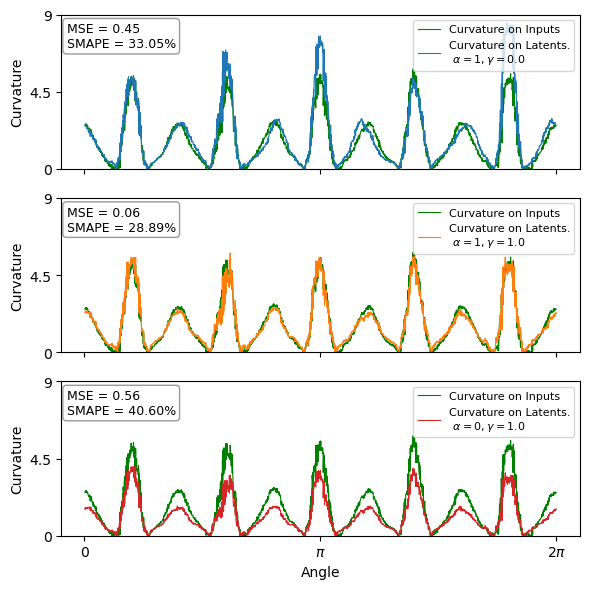

In [31]:
base_path = "notebooks_euclid_ae/curvatures/"
file_paths = [
    "curvatures_exp00_ae_flower_curve_w100_b64_for_plotting.pt",
    "curvatures_exp01_ae_flower_curve_w100_b64_for_plotting.pt",
    "curvatures_exp02_ae_flower_curve_w100_b64_for_plotting.pt",
]
labels = [r"$\alpha=1,\gamma=0.0$", r"$\alpha=1,\gamma=1.0$", r"$\alpha=0,\gamma=1.0$"]
save_path = "plots/euclid_ae_flower_impact_ltopo.png"

plot_curvatures_stacked(base_path=base_path, file_paths=file_paths, labels=labels, ground_truth="emp_curv_ins", save_path=save_path)